In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, wilcoxon
from sklearn.preprocessing import StandardScaler


# =====================================================================
# PATHS
# =====================================================================

ROOT = Path(
    r"A:\NCA_DATA\Validation\2018_HarmonicSensitivity"
)

POINT_CSV = Path(
    r"N:\Data02\projects-active\BOPclassification_2025"
    r"\Field Data (Processed)\2026"
    r"\MasterPointFeatures_2016to2026.csv"
)

VEG_CSV = Path(
    r"C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg.csv"
)

RAW_LONG_CSV = (
    ROOT
    / "PointSampling"
    / "S2_2018_NCA_117Point_HarmonicInputObservations_LONG.csv"
)


# =====================================================================
# RAW COEFFICIENT VRTS
# =====================================================================

VRTS = {
    "K2_12mo": (
        ROOT
        / "VRTs"
        / "2018_K2.vrt"
    ),

    "K3_12mo": (
        ROOT
        / "VRTs"
        / "2018_K3.vrt"
    ),

    "K3_24mo": (
        ROOT
        / "K3_24MonthSupport"
        / "VRTs"
        / "2018_K3_24MonthSupport.vrt"
    ),
}


# =====================================================================
# FUNCTIONAL-GROUP COMPOSITION
#
# These are the ecological dimensions used to define dissimilarity.
# Do NOT include SHRUB_total or total_cover_fg because they duplicate
# information already represented in the component variables.
# =====================================================================

FG_FEATURES = [
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "EAG_FG",
    "EF_FG",
    "LITTER_FG",
    "NPF_FG",
    "PBG_FG",
    "SHRUB_total",
]


# =====================================================================
# SPECTRAL VARIABLES
# =====================================================================

VARIABLES = [
    "B2", "B3", "B4", "B5", "B6",
    "B7", "B8", "B8A", "B11", "B12",
    "NDVI", "NDMI", "NDRE", "BSI", "NBR2",
]


print("Spectral representations:")
for name, path in VRTS.items():
    print(f"  {name}: {path}")

print("\nFunctional-group dimensions:")
print(FG_FEATURES)

Spectral representations:
  K2_12mo: A:\NCA_DATA\Validation\2018_HarmonicSensitivity\VRTs\2018_K2.vrt
  K3_12mo: A:\NCA_DATA\Validation\2018_HarmonicSensitivity\VRTs\2018_K3.vrt
  K3_24mo: A:\NCA_DATA\Validation\2018_HarmonicSensitivity\K3_24MonthSupport\VRTs\2018_K3_24MonthSupport.vrt

Functional-group dimensions:
['BAREGROUND_FG', 'BIOCRUST_FG', 'EAG_FG', 'EF_FG', 'LITTER_FG', 'NPF_FG', 'PBG_FG', 'SHRUB_total']


In [3]:
# =====================================================================
# BUILD THE EXACT 116-PLOT ANALYSIS POPULATION
# =====================================================================

points = pd.read_csv(
    POINT_CSV
)

points["PlotID"] = (
    points["PlotID"]
    .astype(str)
)

points_2018 = (
    points.loc[
        points["Year"] == 2018
    ]
    .copy()
)


veg = pd.read_csv(
    VEG_CSV
)

# Vegetation-table X is an index, not a spatial coordinate.
if "X" in veg.columns:
    veg = veg.drop(
        columns="X"
    )

veg["Plot"] = (
    veg["Plot"]
    .astype(str)
)

veg_2018 = (
    veg.loc[
        veg["Year"] == 2018
    ]
    .copy()
)


# ---------------------------------------------------------------------
# The long S2 table tells us which field plots actually have enough
# valid 2018 Sentinel-2 observations to participate in the harmonic
# analysis.
# ---------------------------------------------------------------------

raw_long = pd.read_csv(
    RAW_LONG_CSV
)

raw_long["PlotID"] = (
    raw_long["PlotID"]
    .astype(str)
)

valid_plot_ids = set(
    raw_long["PlotID"].unique()
)

print(
    "Plots with valid 2018 harmonic observations:",
    len(valid_plot_ids)
)


# ---------------------------------------------------------------------
# Join field coordinates to vegetation.
# ---------------------------------------------------------------------

analysis_plots = (
    points_2018[
        ["PlotID", "X", "Y"]
    ]
    .merge(
        veg_2018[
            ["Plot"] + FG_FEATURES
        ],
        left_on="PlotID",
        right_on="Plot",
        how="inner",
        validate="one_to_one",
    )
    .drop(
        columns="Plot"
    )
)


# Restrict to the valid harmonic population.
analysis_plots = (
    analysis_plots.loc[
        analysis_plots["PlotID"].isin(
            valid_plot_ids
        )
    ]
    .copy()
    .sort_values("PlotID")
    .reset_index(drop=True)
)


print(
    "Final aligned analysis plots:",
    len(analysis_plots)
)

display(
    analysis_plots.head()
)

Plots with valid 2018 harmonic observations: 116
Final aligned analysis plots: 116


,PlotID,X,Y,BAREGROUND_FG,BIOCRUST_FG,EAG_FG,EF_FG,LITTER_FG,NPF_FG,PBG_FG,SHRUB_total
0,101,600918,4778343,0.000000,26.12,48.633333,3.400000,5.766667,0.0,0.000000,13.950000
1,102,600857,4778254,5.160000,44.20,15.100000,9.780000,13.440000,0.0,0.400000,11.820000
2,103,600712,4778038,0.333333,12.25,74.483333,2.383333,6.800000,0.0,0.333333,2.733333
3,104,600540,4775722,7.640000,17.56,20.066667,2.033333,30.266667,0.0,2.033333,19.050000
4,105,600101,4775759,33.140000,10.90,0.000000,1.620000,16.720000,0.0,0.820000,36.720000


In [4]:
print(
    analysis_plots[FG_FEATURES]
    .isna()
    .sum()
)

print(
    "\nFunctional-group ranges:"
)

display(
    analysis_plots[FG_FEATURES]
    .agg(["min", "median", "mean", "max"])
    .T
)

BAREGROUND_FG    0
BIOCRUST_FG      0
EAG_FG           0
EF_FG            0
LITTER_FG        0
NPF_FG           0
PBG_FG           0
SHRUB_total      0
dtype: int64

Functional-group ranges:


,min,median,mean,max
BAREGROUND_FG,0.0,27.243333,29.029307,100.000000
BIOCRUST_FG,0.0,6.126667,10.834316,66.666667
EAG_FG,0.0,1.420000,16.938592,98.380000
EF_FG,0.0,0.541667,8.750041,67.760000
LITTER_FG,0.0,12.640000,16.222385,53.480000
NPF_FG,0.0,0.000000,0.000000,0.000000
PBG_FG,0.0,0.400000,9.758376,61.240000
SHRUB_total,0.0,0.000000,8.058103,51.440000


In [11]:
for model_name, vrt_path in VRTS.items():

    with rasterio.open(vrt_path) as src:

        print("\n", model_name)
        print("Band count:", src.count)
        print("First 10 descriptions:")
        print(src.descriptions[:10])


 K2_12mo
Band count: 91
First 10 descriptions:
(None, None, None, None, None, None, None, None, None, None)

 K3_12mo
Band count: 121
First 10 descriptions:
(None, None, None, None, None, None, None, None, None, None)

 K3_24mo
Band count: 122
First 10 descriptions:
(None, None, None, None, None, None, None, None, None, None)


In [12]:
# =====================================================================
# DEFINE RAW HARMONIC COEFFICIENT SCHEMA BY BAND POSITION
# =====================================================================

def coefficient_schema(
    k,
    variables=VARIABLES,
):
    """
    Reconstruct the known GEE export order of harmonic coefficients.

    These are the spectral-state features only:
        constant
        sin1 / cos1
        ...
        sinK / cosK

    nobs and RMSE bands are intentionally excluded.
    """

    names = []

    # Intercepts
    names.extend(
        [
            f"constant_{variable}"
            for variable in variables
        ]
    )

    # Harmonic coefficients
    for h in range(1, k + 1):

        names.extend(
            [
                f"sin{h}_{variable}"
                for variable in variables
            ]
        )

        names.extend(
            [
                f"cos{h}_{variable}"
                for variable in variables
            ]
        )

    return names

In [13]:
for k in [2, 3]:

    names = coefficient_schema(k)

    print(
        f"K{k}: "
        f"{len(names)} coefficient features"
    )

    print("First 5:")
    print(names[:5])

    print("Last 5:")
    print(names[-5:])

    print()

K2: 75 coefficient features
First 5:
['constant_B2', 'constant_B3', 'constant_B4', 'constant_B5', 'constant_B6']
Last 5:
['cos2_NDVI', 'cos2_NDMI', 'cos2_NDRE', 'cos2_BSI', 'cos2_NBR2']

K3: 105 coefficient features
First 5:
['constant_B2', 'constant_B3', 'constant_B4', 'constant_B5', 'constant_B6']
Last 5:
['cos3_NDVI', 'cos3_NDMI', 'cos3_NDRE', 'cos3_BSI', 'cos3_NBR2']



In [14]:
# =====================================================================
# VALIDATE RAW VRT BAND COUNTS
# =====================================================================

EXPECTED_TOTAL_BANDS = {
    "K2_12mo": 91,
    "K3_12mo": 121,
    "K3_24mo": 122,
}


for model_name, vrt_path in VRTS.items():

    with rasterio.open(vrt_path) as src:

        expected = EXPECTED_TOTAL_BANDS[
            model_name
        ]

        print(
            f"{model_name}: "
            f"{src.count} bands "
            f"(expected {expected})"
        )

        assert src.count == expected, (
            f"{model_name} has {src.count} bands; "
            f"expected {expected}."
        )

K2_12mo: 91 bands (expected 91)
K3_12mo: 121 bands (expected 121)
K3_24mo: 122 bands (expected 122)


In [15]:
# =====================================================================
# SAMPLE RAW HARMONIC COEFFICIENTS BY KNOWN BAND POSITION
# =====================================================================

def sample_coefficient_vrt(
    vrt_path,
    plots,
    k,
):
    """
    Sample the harmonic coefficient portion of a raw VRT.

    Band order is reconstructed from the known GEE export schema.

    Rasterio uses 1-based band indexing.
    """

    feature_names = coefficient_schema(
        k=k,
        variables=VARIABLES,
    )

    n_features = len(
        feature_names
    )

    # Because harmonic coefficients occupy the FIRST bands
    # in the export, their raster band indexes are simply:
    #
    # 1 ... 75 for K2
    # 1 ... 105 for K3
    #
    indexes = list(
        range(
            1,
            n_features + 1,
        )
    )

    coordinates = list(
        zip(
            plots["X"],
            plots["Y"],
        )
    )

    with rasterio.open(
        vrt_path
    ) as src:

        if src.count < n_features:
            raise ValueError(
                f"{vrt_path.name} contains "
                f"{src.count} bands but "
                f"{n_features} coefficient bands "
                f"are required."
            )

        sampled = np.array(
            list(
                src.sample(
                    coordinates,
                    indexes=indexes,
                    masked=True,
                )
            )
        )

    sampled = np.ma.filled(
        sampled,
        np.nan,
    ).astype(float)

    result = pd.DataFrame(
        sampled,
        columns=feature_names,
    )

    result.insert(
        0,
        "PlotID",
        plots["PlotID"].astype(str).to_numpy(),
    )

    return result

In [16]:
# =====================================================================
# SAMPLE ALL THREE REPRESENTATIONS
# =====================================================================

spectral_samples = {}


for model_name, vrt_path in VRTS.items():

    k = (
        2
        if model_name == "K2_12mo"
        else 3
    )

    spectral_samples[
        model_name
    ] = sample_coefficient_vrt(
        vrt_path=vrt_path,
        plots=analysis_plots,
        k=k,
    )

    print(
        f"{model_name}: "
        f"{spectral_samples[model_name].shape}"
    )

K2_12mo: (116, 76)
K3_12mo: (116, 106)
K3_24mo: (116, 106)


In [17]:
# =====================================================================
# ECOLOGICAL REFERENCE SPACE — FUNCTIONAL-GROUP COMPOSITION
# =====================================================================

FG_FEATURES = [
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "EAG_FG",
    "EF_FG",
    "LITTER_FG",
    "NPF_FG",
    "PBG_FG",
    "SHRUB_total",
]


fg_table = (
    analysis_plots[
        ["PlotID"] + FG_FEATURES
    ]
    .copy()
)


# ---------------------------------------------------------------------
# Basic QA
# ---------------------------------------------------------------------

print("Functional-group table shape:")
print(fg_table.shape)

print("\nMissing values:")
display(
    fg_table[
        FG_FEATURES
    ]
    .isna()
    .sum()
    .to_frame("n_missing")
)

print("\nNegative values:")
display(
    (
        fg_table[
            FG_FEATURES
        ] < 0
    )
    .sum()
    .to_frame("n_negative")
)

print("\nFunctional-group summary:")
display(
    fg_table[
        FG_FEATURES
    ]
    .agg([
        "min",
        "median",
        "mean",
        "max",
    ])
    .T
)


# ---------------------------------------------------------------------
# Diagnostic only:
# sum of the selected composition components
# ---------------------------------------------------------------------

fg_table["FG_component_sum"] = (
    fg_table[
        FG_FEATURES
    ]
    .sum(axis=1)
)

print("\nSelected FG component sum:")
display(
    fg_table[
        "FG_component_sum"
    ]
    .describe()
)

Functional-group table shape:
(116, 9)

Missing values:


,n_missing
BAREGROUND_FG,0
BIOCRUST_FG,0
EAG_FG,0
EF_FG,0
LITTER_FG,0
NPF_FG,0
PBG_FG,0
SHRUB_total,0



Negative values:


,n_negative
BAREGROUND_FG,0
BIOCRUST_FG,0
EAG_FG,0
EF_FG,0
LITTER_FG,0
NPF_FG,0
PBG_FG,0
SHRUB_total,0



Functional-group summary:


,min,median,mean,max
BAREGROUND_FG,0.0,27.243333,29.029307,100.000000
BIOCRUST_FG,0.0,6.126667,10.834316,66.666667
EAG_FG,0.0,1.420000,16.938592,98.380000
EF_FG,0.0,0.541667,8.750041,67.760000
LITTER_FG,0.0,12.640000,16.222385,53.480000
NPF_FG,0.0,0.000000,0.000000,0.000000
PBG_FG,0.0,0.400000,9.758376,61.240000
SHRUB_total,0.0,0.000000,8.058103,51.440000



Selected FG component sum:


count    116.000000
mean      99.591121
std        0.821814
min       92.620000
25%       99.469167
50%       99.920000
75%       99.962500
max      100.020000
Name: FG_component_sum, dtype: float64

In [18]:
from scipy.spatial.distance import pdist, squareform


# =====================================================================
# BRAY-CURTIS FUNCTIONAL-GROUP DISSIMILARITY
# =====================================================================

FG = (
    fg_table[
        FG_FEATURES
    ]
    .to_numpy(
        dtype=float
    )
)


if np.isnan(FG).any():
    raise ValueError(
        "Functional-group matrix contains NaN values."
    )

if (FG < 0).any():
    raise ValueError(
        "Functional-group matrix contains negative values."
    )


# Condensed vector:
# one value for every unique pair of plots.
fg_distance_condensed = pdist(
    FG,
    metric="braycurtis",
)


# Full symmetric 116 x 116 matrix.
FG_DISTANCE = squareform(
    fg_distance_condensed
)


n_plots = len(
    fg_table
)

n_pairs = len(
    fg_distance_condensed
)


print(
    f"Plots: {n_plots}"
)

print(
    f"Unique plot pairs: {n_pairs}"
)

print(
    f"Expected pairs: "
    f"{n_plots * (n_plots - 1) // 2}"
)

print(
    f"\nBray-Curtis range: "
    f"{fg_distance_condensed.min():.4f} "
    f"to "
    f"{fg_distance_condensed.max():.4f}"
)

print(
    f"Median Bray-Curtis: "
    f"{np.median(fg_distance_condensed):.4f}"
)

Plots: 116
Unique plot pairs: 6670
Expected pairs: 6670

Bray-Curtis range: 0.0000 to 1.0000
Median Bray-Curtis: 0.5617


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# =====================================================================
# PCA — THREE HARMONIC REPRESENTATIONS
# =====================================================================

pca_results = {}


for model_name, df in spectral_samples.items():

    feature_cols = [
        col
        for col in df.columns
        if col != "PlotID"
    ]

    X = (
        df[feature_cols]
        .to_numpy(dtype=float)
    )

    # -------------------------------------------------------------
    # Standardize each harmonic coefficient:
    #
    # z = (x - mean) / standard deviation
    #
    # PCA therefore responds to covariance structure among
    # standardized spectral features rather than raw units.
    # -------------------------------------------------------------

    scaler = StandardScaler()

    Xz = scaler.fit_transform(
        X
    )

    # -------------------------------------------------------------
    # Full PCA
    # -------------------------------------------------------------

    pca = PCA()

    scores = pca.fit_transform(
        Xz
    )

    # Plot coordinates in PCA space.
    score_df = pd.DataFrame(
        {
            "PlotID": (
                df["PlotID"]
                .astype(str)
                .to_numpy()
            ),
            **{
                f"PC{i + 1}": scores[:, i]
                for i in range(
                    scores.shape[1]
                )
            },
        }
    )

    # Feature loadings.
    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_cols,
        columns=[
            f"PC{i + 1}"
            for i in range(
                pca.components_.shape[0]
            )
        ],
    )

    pca_results[
        model_name
    ] = {
        "features": feature_cols,
        "X_standardized": Xz,
        "scaler": scaler,
        "pca": pca,
        "scores": score_df,
        "loadings": loadings,
    }


    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    for i in range(5):

        print(
            f"PC{i + 1}: "
            f"{pca.explained_variance_ratio_[i]:.4f} "
            f"("
            f"{100 * pca.explained_variance_ratio_[i]:.2f}%"
            f")"
        )

    print(
        "\nPC1–PC2 cumulative: "
        f"{100 * pca.explained_variance_ratio_[:2].sum():.2f}%"
    )

    print(
        "PC1–PC3 cumulative: "
        f"{100 * pca.explained_variance_ratio_[:3].sum():.2f}%"
    )

    print(
        "PC1–PC5 cumulative: "
        f"{100 * pca.explained_variance_ratio_[:5].sum():.2f}%"
    )


K2_12mo
PC1: 0.3029 (30.29%)
PC2: 0.2121 (21.21%)
PC3: 0.1064 (10.64%)
PC4: 0.0910 (9.10%)
PC5: 0.0660 (6.60%)

PC1–PC2 cumulative: 51.50%
PC1–PC3 cumulative: 62.15%
PC1–PC5 cumulative: 77.85%

K3_12mo
PC1: 0.3324 (33.24%)
PC2: 0.1971 (19.71%)
PC3: 0.1131 (11.31%)
PC4: 0.0784 (7.84%)
PC5: 0.0571 (5.71%)

PC1–PC2 cumulative: 52.95%
PC1–PC3 cumulative: 64.26%
PC1–PC5 cumulative: 77.81%

K3_24mo
PC1: 0.2585 (25.85%)
PC2: 0.1319 (13.19%)
PC3: 0.1088 (10.88%)
PC4: 0.0964 (9.64%)
PC5: 0.0789 (7.89%)

PC1–PC2 cumulative: 39.03%
PC1–PC3 cumulative: 49.91%
PC1–PC5 cumulative: 67.44%


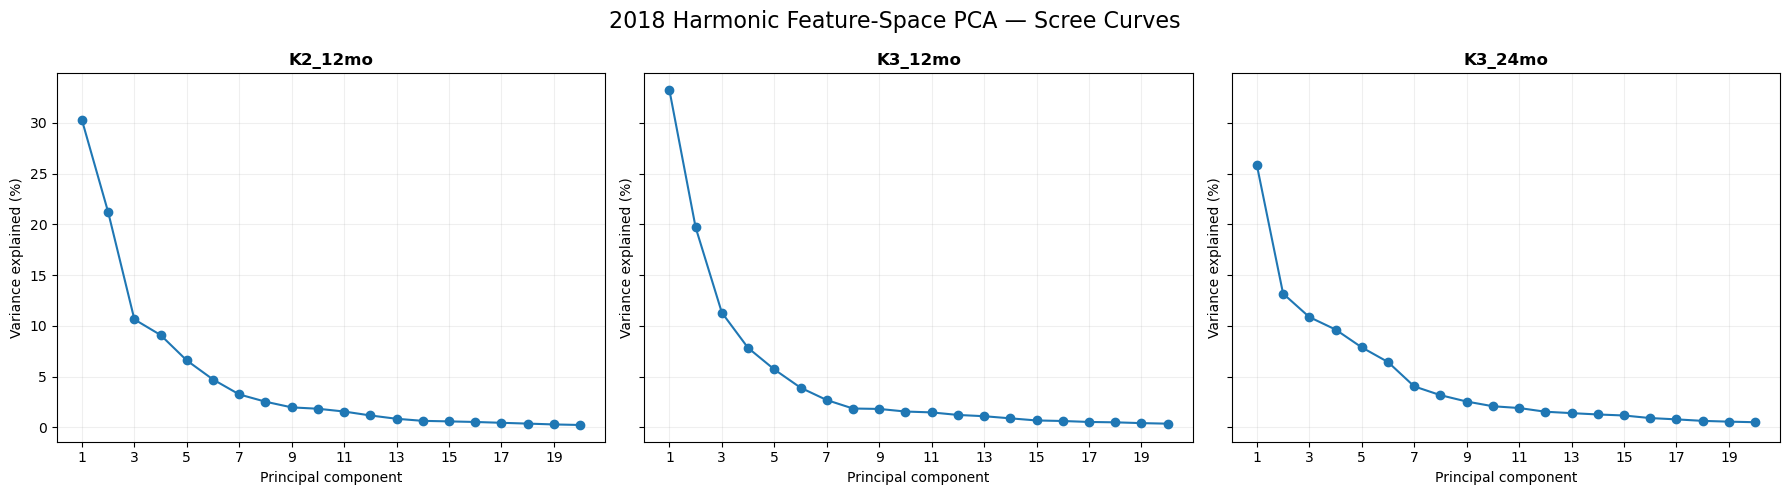

In [20]:
# =====================================================================
# SCREE CURVES
# =====================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharey=True,
)


MODEL_ORDER = [
    "K2_12mo",
    "K3_12mo",
    "K3_24mo",
]


for ax, model_name in zip(
    axes,
    MODEL_ORDER,
):

    pca = pca_results[
        model_name
    ]["pca"]

    variance = (
        pca.explained_variance_ratio_
        * 100
    )

    n_show = min(
        20,
        len(variance),
    )

    pcs = np.arange(
        1,
        n_show + 1,
    )

    ax.plot(
        pcs,
        variance[:n_show],
        marker="o",
    )

    ax.set_title(
        model_name,
        fontweight="bold",
    )

    ax.set_xlabel(
        "Principal component"
    )

    ax.set_ylabel(
        "Variance explained (%)"
    )

    ax.set_xticks(
        np.arange(
            1,
            n_show + 1,
            2,
        )
    )

    ax.grid(
        alpha=0.2
    )


fig.suptitle(
    "2018 Harmonic Feature-Space PCA — Scree Curves",
    fontsize=16,
)

fig.tight_layout()
plt.show()

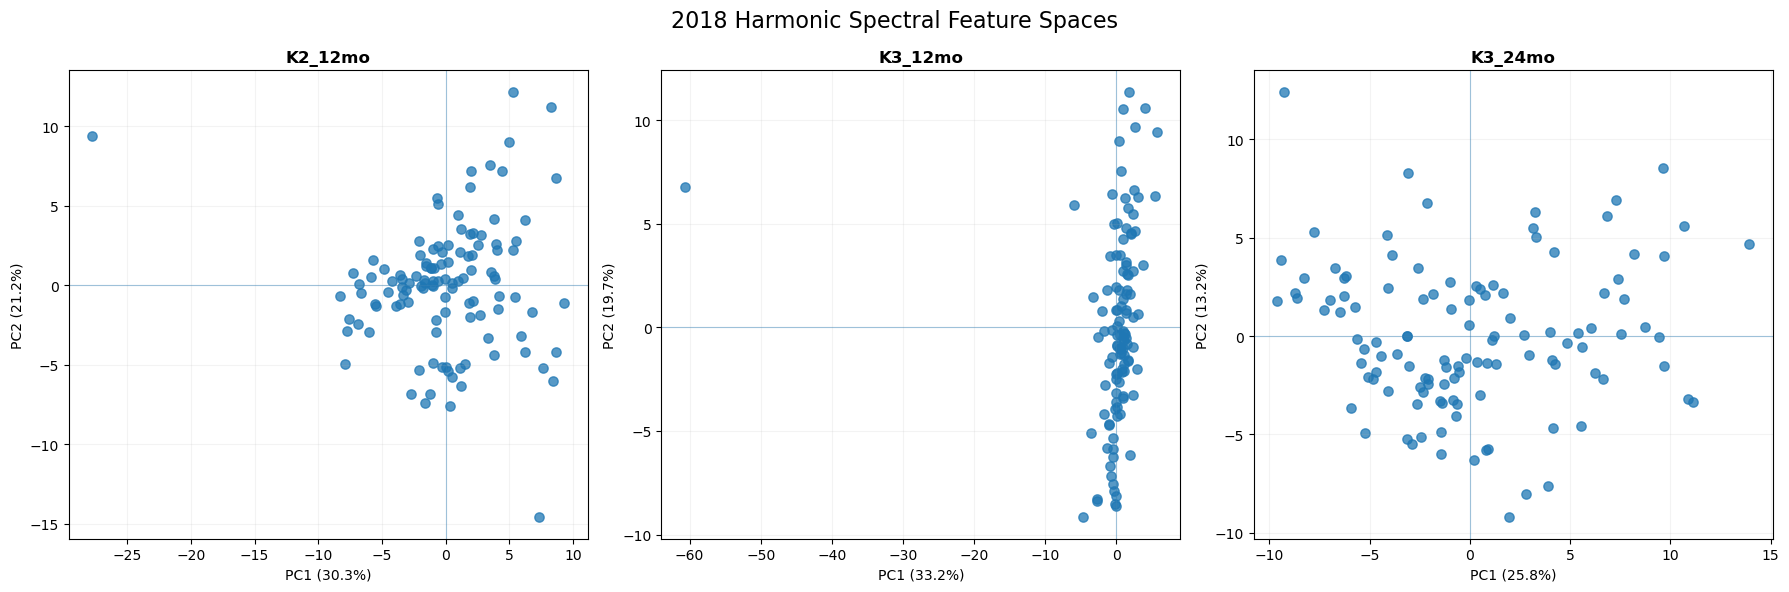

In [21]:
# =====================================================================
# PC1 vs PC2 — RAW SPECTRAL GEOMETRY
# =====================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
)


for ax, model_name in zip(
    axes,
    MODEL_ORDER,
):

    scores = pca_results[
        model_name
    ]["scores"]

    pca = pca_results[
        model_name
    ]["pca"]

    ax.scatter(
        scores["PC1"],
        scores["PC2"],
        s=45,
        alpha=0.75,
    )

    ax.axhline(
        0,
        linewidth=0.8,
        alpha=0.4,
    )

    ax.axvline(
        0,
        linewidth=0.8,
        alpha=0.4,
    )

    pc1_var = (
        pca.explained_variance_ratio_[0]
        * 100
    )

    pc2_var = (
        pca.explained_variance_ratio_[1]
        * 100
    )

    ax.set_xlabel(
        f"PC1 ({pc1_var:.1f}%)"
    )

    ax.set_ylabel(
        f"PC2 ({pc2_var:.1f}%)"
    )

    ax.set_title(
        model_name,
        fontweight="bold",
    )

    ax.grid(
        alpha=0.15
    )


fig.suptitle(
    "2018 Harmonic Spectral Feature Spaces",
    fontsize=16,
)

fig.tight_layout()
plt.show()

In [25]:
# =====================================================================
# IDENTIFY PCA EXTREMES
# =====================================================================

for model_name in MODEL_ORDER:

    scores = (
        pca_results[
            model_name
        ]["scores"]
        .copy()
    )

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print("\nMost negative PC1:")
    display(
        scores.nsmallest(
            5,
            "PC1"
        )[
            [
                "PlotID",
                "PC1",
                "PC2",
                "PC3",
            ]
        ]
    )

    print("\nMost positive PC1:")
    display(
        scores.nlargest(
            5,
            "PC1"
        )[
            [
                "PlotID",
                "PC1",
                "PC2",
                "PC3",
            ]
        ]
    )


K2_12mo

Most negative PC1:


,PlotID,PC1,PC2,PC3
58,202,-27.750184,9.370246,-2.640816
97,273,-8.306435,-0.656236,0.184975
27,130,-7.870519,-4.930512,3.488169
14,116,-7.761338,-2.895333,2.810389
96,272,-7.577279,-2.132839,1.101164



Most positive PC1:


,PlotID,PC1,PC2,PC3
30,133,9.308088,-1.116687,-2.210008
86,232,8.674600,6.774686,0.166100
53,197,8.643288,-4.187618,0.313460
56,200,8.461293,-6.023981,-5.108867
77,223,8.302462,11.191608,5.861293



K3_12mo

Most negative PC1:


...

,PlotID,PC1,PC2,PC3
77,223,5.696556,9.406626,9.116656
78,224,5.432550,6.316171,7.858859
56,200,4.101796,10.558557,-7.253126
5,106,3.752682,2.990389,4.942652
68,213,3.136114,0.639471,3.960443



K3_24mo

Most negative PC1:


,PlotID,PC1,PC2,PC3
11,112,-9.597022,1.790545,-1.804534
97,273,-9.397557,3.889832,1.328200
58,202,-9.268146,12.432211,1.539006
70,215,-8.716297,2.200112,-5.629276
69,214,-8.644300,1.948121,-1.562087



Most positive PC1:


,PlotID,PC1,PC2,PC3
56,200,13.932697,4.693705,0.791737
46,189,11.118863,-3.346942,-2.923876
30,133,10.888603,-3.193215,1.722663
37,144,10.698696,5.584828,3.006123
53,197,9.700503,-1.530440,-4.381821


In [26]:
# =====================================================================
# REMOVE KNOWN PATHOLOGICAL PLOT 202 FOR PCA SENSITIVITY ANALYSIS
# =====================================================================

EXCLUDE_PLOTS = ["202"]

spectral_samples_no202 = {}

for model_name, df in spectral_samples.items():

    filtered = (
        df.loc[
            ~df["PlotID"]
            .astype(str)
            .isin(EXCLUDE_PLOTS)
        ]
        .copy()
        .reset_index(drop=True)
    )

    spectral_samples_no202[
        model_name
    ] = filtered

    print(
        f"{model_name}: "
        f"{len(df)} -> {len(filtered)} plots"
    )


# Confirm identical paired population
reference_ids = (
    spectral_samples_no202["K2_12mo"]["PlotID"]
    .astype(str)
    .tolist()
)

for model_name, df in spectral_samples_no202.items():

    assert (
        df["PlotID"]
        .astype(str)
        .tolist()
        == reference_ids
    )

print(
    "\nPaired PCA population:",
    len(reference_ids)
)

assert len(reference_ids) == 115
assert "202" not in reference_ids

K2_12mo: 116 -> 115 plots
K3_12mo: 116 -> 115 plots
K3_24mo: 116 -> 115 plots

Paired PCA population: 115


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# =====================================================================
# PCA WITHOUT PLOT 202
# =====================================================================

pca_results_no202 = {}


for model_name, df in spectral_samples_no202.items():

    feature_cols = [
        col
        for col in df.columns
        if col != "PlotID"
    ]

    X = (
        df[feature_cols]
        .to_numpy(dtype=float)
    )

    # -------------------------------------------------------------
    # Standardize within each candidate feature representation.
    # -------------------------------------------------------------

    scaler = StandardScaler()

    Xz = scaler.fit_transform(
        X
    )

    # -------------------------------------------------------------
    # PCA
    # -------------------------------------------------------------

    pca = PCA()

    scores = pca.fit_transform(
        Xz
    )

    score_df = pd.DataFrame(
        {
            "PlotID": (
                df["PlotID"]
                .astype(str)
                .to_numpy()
            ),
            **{
                f"PC{i + 1}": scores[:, i]
                for i in range(
                    scores.shape[1]
                )
            },
        }
    )

    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_cols,
        columns=[
            f"PC{i + 1}"
            for i in range(
                pca.components_.shape[0]
            )
        ],
    )

    pca_results_no202[
        model_name
    ] = {
        "features": feature_cols,
        "X_standardized": Xz,
        "scaler": scaler,
        "pca": pca,
        "scores": score_df,
        "loadings": loadings,
    }


    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    for i in range(5):

        explained = (
            pca.explained_variance_ratio_[i]
        )

        print(
            f"PC{i + 1}: "
            f"{explained:.4f} "
            f"({100 * explained:.2f}%)"
        )

    print(
        "\nPC1–PC2 cumulative: "
        f"{100 * pca.explained_variance_ratio_[:2].sum():.2f}%"
    )

    print(
        "PC1–PC3 cumulative: "
        f"{100 * pca.explained_variance_ratio_[:3].sum():.2f}%"
    )

    print(
        "PC1–PC5 cumulative: "
        f"{100 * pca.explained_variance_ratio_[:5].sum():.2f}%"
    )


K2_12mo
PC1: 0.2729 (27.29%)
PC2: 0.2205 (22.05%)
PC3: 0.1219 (12.19%)
PC4: 0.0978 (9.78%)
PC5: 0.0592 (5.92%)

PC1–PC2 cumulative: 49.34%
PC1–PC3 cumulative: 61.52%
PC1–PC5 cumulative: 77.22%

K3_12mo
PC1: 0.2565 (25.65%)
PC2: 0.1677 (16.77%)
PC3: 0.1034 (10.34%)
PC4: 0.0978 (9.78%)
PC5: 0.0760 (7.60%)

PC1–PC2 cumulative: 42.42%
PC1–PC3 cumulative: 52.75%
PC1–PC5 cumulative: 70.13%

K3_24mo
PC1: 0.2618 (26.18%)
PC2: 0.1312 (13.12%)
PC3: 0.1133 (11.33%)
PC4: 0.0893 (8.93%)
PC5: 0.0816 (8.16%)

PC1–PC2 cumulative: 39.30%
PC1–PC3 cumulative: 50.63%
PC1–PC5 cumulative: 67.72%


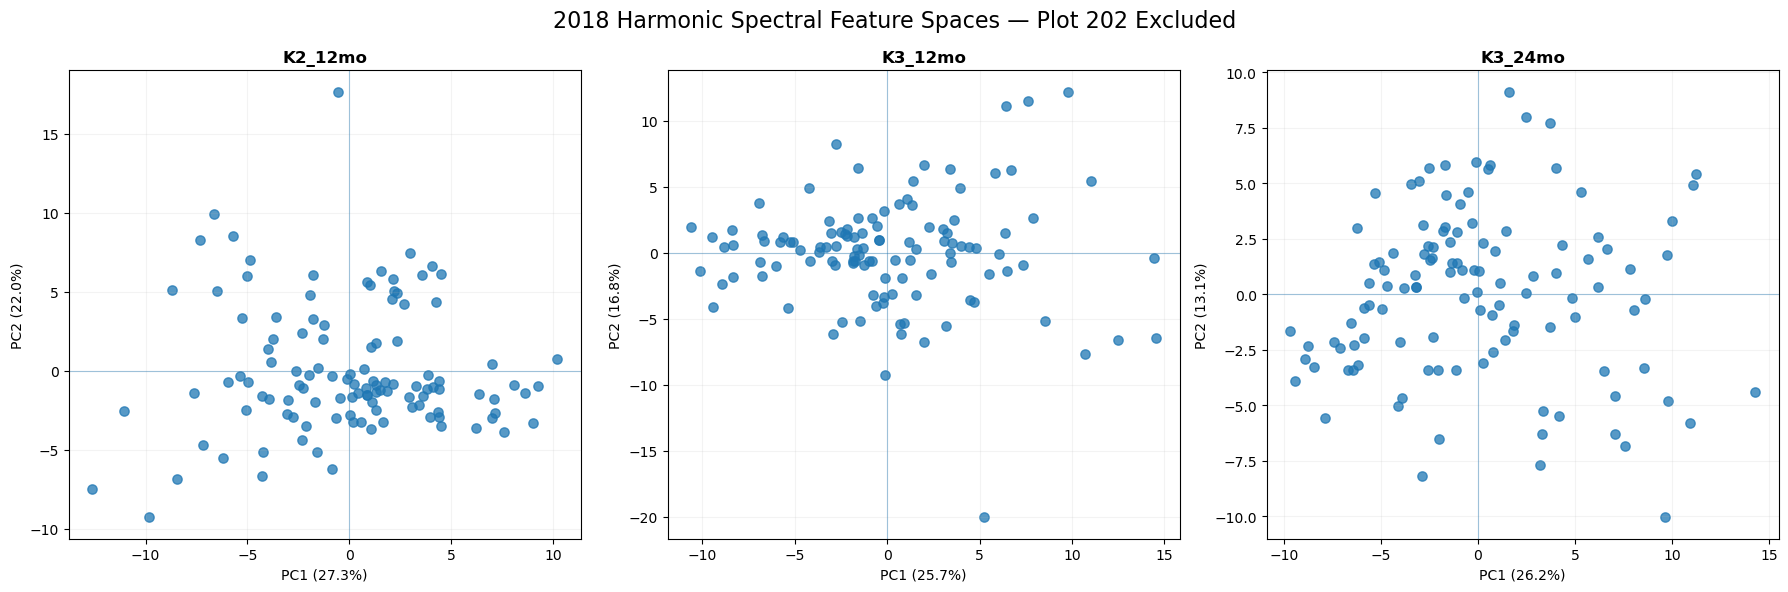

In [28]:
# =====================================================================
# PC1 vs PC2 — PLOT 202 REMOVED
# =====================================================================

MODEL_ORDER = [
    "K2_12mo",
    "K3_12mo",
    "K3_24mo",
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
)


for ax, model_name in zip(
    axes,
    MODEL_ORDER,
):

    scores = (
        pca_results_no202[
            model_name
        ]["scores"]
    )

    pca = (
        pca_results_no202[
            model_name
        ]["pca"]
    )

    ax.scatter(
        scores["PC1"],
        scores["PC2"],
        s=45,
        alpha=0.75,
    )

    ax.axhline(
        0,
        linewidth=0.8,
        alpha=0.4,
    )

    ax.axvline(
        0,
        linewidth=0.8,
        alpha=0.4,
    )

    pc1_var = (
        pca.explained_variance_ratio_[0]
        * 100
    )

    pc2_var = (
        pca.explained_variance_ratio_[1]
        * 100
    )

    ax.set_xlabel(
        f"PC1 ({pc1_var:.1f}%)"
    )

    ax.set_ylabel(
        f"PC2 ({pc2_var:.1f}%)"
    )

    ax.set_title(
        model_name,
        fontweight="bold",
    )

    ax.grid(
        alpha=0.15
    )


fig.suptitle(
    "2018 Harmonic Spectral Feature Spaces — Plot 202 Excluded",
    fontsize=16,
)

fig.tight_layout()
plt.show()

In [22]:
import re


def parse_harmonic_feature(
    feature_name
):

    # -------------------------------------------------------------
    # Intercept
    # -------------------------------------------------------------

    if feature_name.startswith(
        "constant_"
    ):

        variable = (
            feature_name
            .replace(
                "constant_",
                ""
            )
        )

        return {
            "feature": feature_name,
            "variable": variable,
            "component": "Intercept",
            "harmonic": 0,
            "term": "constant",
        }


    # -------------------------------------------------------------
    # Harmonic sin / cos terms
    # -------------------------------------------------------------

    match = re.match(
        r"(sin|cos)(\d+)_(.+)",
        feature_name,
    )

    if match is None:
        raise ValueError(
            f"Could not parse harmonic feature: "
            f"{feature_name}"
        )

    term = match.group(1)

    harmonic = int(
        match.group(2)
    )

    variable = match.group(3)

    return {
        "feature": feature_name,
        "variable": variable,
        "component": f"K{harmonic}",
        "harmonic": harmonic,
        "term": term,
    }


# Quick QA
examples = [
    "constant_B8A",
    "sin1_NDVI",
    "cos2_B11",
    "sin3_NBR2",
]

for feature in examples:
    print(
        parse_harmonic_feature(
            feature
        )
    )

{'feature': 'constant_B8A', 'variable': 'B8A', 'component': 'Intercept', 'harmonic': 0, 'term': 'constant'}
{'feature': 'sin1_NDVI', 'variable': 'NDVI', 'component': 'K1', 'harmonic': 1, 'term': 'sin'}
{'feature': 'cos2_B11', 'variable': 'B11', 'component': 'K2', 'harmonic': 2, 'term': 'cos'}
{'feature': 'sin3_NBR2', 'variable': 'NBR2', 'component': 'K3', 'harmonic': 3, 'term': 'sin'}


In [23]:
# =====================================================================
# COEFFICIENT-LEVEL PCA IMPORTANCE
# =====================================================================

pca_feature_importance = {}


for model_name in MODEL_ORDER:

    loadings = pca_results[
        model_name
    ]["loadings"]

    rows = []

    for feature in loadings.index:

        metadata = (
            parse_harmonic_feature(
                feature
            )
        )

        for pc in [
            "PC1",
            "PC2",
            "PC3",
        ]:

            loading = (
                loadings.loc[
                    feature,
                    pc
                ]
            )

            rows.append(
                {
                    **metadata,
                    "PC": pc,
                    "loading": loading,
                    "importance": (
                        loading ** 2
                    ),
                }
            )

    importance_df = pd.DataFrame(
        rows
    )

    pca_feature_importance[
        model_name
    ] = importance_df

In [24]:
display(
    pca_feature_importance[
        "K3_12mo"
    ]
    .sort_values(
        [
            "PC",
            "importance",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .groupby(
        "PC",
        group_keys=False,
    )
    .head(15)
)

,feature,variable,component,harmonic,term,PC,loading,importance
234,sin3_B5,B5,K3,3,sin,PC1,0.159227,0.025353
252,sin3_B12,B12,K3,3,sin,PC1,0.157956,0.024950
249,sin3_B11,B11,K3,3,sin,PC1,0.155854,0.024290
294,cos3_B11,B11,K3,3,cos,PC1,0.152604,0.023288
162,sin2_B12,B12,K2,2,sin,PC1,-0.152237,0.023176
159,sin2_B11,B11,K2,2,sin,PC1,-0.151722,0.023020
237,sin3_B6,B6,K3,3,sin,PC1,0.151595,0.022981
297,cos3_B12,B12,K3,3,cos,PC1,0.150237,0.022571
144,sin2_B5,B5,K2,2,sin,PC1,-0.148540,0.022064
276,cos3_B4,B4,K3,3,cos,PC1,0.144730,0.020947


In [29]:
# =====================================================================
# RECOMPUTE PCA FEATURE IMPORTANCE — PLOT 202 EXCLUDED
# =====================================================================

pca_feature_importance_no202 = {}


for model_name in MODEL_ORDER:

    loadings = (
        pca_results_no202[
            model_name
        ]["loadings"]
    )

    rows = []

    for feature in loadings.index:

        metadata = (
            parse_harmonic_feature(
                feature
            )
        )

        for pc in [
            "PC1",
            "PC2",
            "PC3",
        ]:

            loading = (
                loadings.loc[
                    feature,
                    pc
                ]
            )

            rows.append(
                {
                    **metadata,
                    "PC": pc,
                    "loading": loading,
                    "importance": loading ** 2,
                }
            )

    pca_feature_importance_no202[
        model_name
    ] = pd.DataFrame(
        rows
    )

In [30]:
# =====================================================================
# HARMONIC-ORDER CONTRIBUTION — PLOT 202 EXCLUDED
# =====================================================================

pca_harmonic_importance_no202 = {}


for model_name in MODEL_ORDER:

    importance = (
        pca_feature_importance_no202[
            model_name
        ]
    )

    summary = (
        importance
        .groupby(
            [
                "PC",
                "component",
            ],
            as_index=False,
        )
        ["importance"]
        .sum()
    )

    pca_harmonic_importance_no202[
        model_name
    ] = summary


for model_name in MODEL_ORDER:

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    table = (
        pca_harmonic_importance_no202[
            model_name
        ]
        .pivot(
            index="component",
            columns="PC",
            values="importance",
        )
    )

    display(table)


K2_12mo


PC,PC1,PC2,PC3
component,,,
Intercept,0.320583,0.031535,0.197881
K1,0.462706,0.419649,0.380943
K2,0.216712,0.548816,0.421176



K3_12mo


PC,PC1,PC2,PC3
component,,,
Intercept,0.183239,0.042399,0.236237
K1,0.337400,0.395098,0.207248
K2,0.230676,0.378502,0.143496
K3,0.248686,0.184001,0.413019



K3_24mo


PC,PC1,PC2,PC3
component,,,
Intercept,0.103688,0.288078,0.104405
K1,0.340912,0.074596,0.394714
K2,0.285822,0.243472,0.313619
K3,0.269578,0.393855,0.187262


In [34]:
from scipy.stats import spearmanr


# =====================================================================
# FUNCTIONAL GROUPS USED FOR PCA ASSOCIATION
#
# NPF_FG is excluded because it is constant across the 115-plot
# analysis population, so Spearman rho is undefined.
# =====================================================================

FG_FEATURES_FOR_PCA = [
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "EAG_FG",
    "EF_FG",
    "LITTER_FG",
    "PBG_FG",
    "SHRUB_total",
]


# =====================================================================
# JOIN FUNCTIONAL-GROUP COMPOSITION TO PCA SCORES — PLOT 202 EXCLUDED
# =====================================================================

fg_table_no202 = (
    fg_table.loc[
        fg_table["PlotID"].astype(str) != "202"
    ]
    .copy()
)


pca_ecology_no202 = {}


for model_name in MODEL_ORDER:

    scores = (
        pca_results_no202[
            model_name
        ]["scores"]
        [
            [
                "PlotID",
                "PC1",
                "PC2",
                "PC3",
            ]
        ]
        .copy()
    )

    merged = (
        scores
        .merge(
            fg_table_no202[
                ["PlotID"] + FG_FEATURES_FOR_PCA
            ],
            on="PlotID",
            how="inner",
            validate="one_to_one",
        )
    )

    pca_ecology_no202[
        model_name
    ] = merged

    print(
        model_name,
        merged.shape,
    )

K2_12mo (115, 11)
K3_12mo (115, 11)
K3_24mo (115, 11)


In [35]:
# =====================================================================
# FUNCTIONAL-GROUP ASSOCIATION WITH PC1–PC3
# =====================================================================

fg_pc_associations_no202 = []


for model_name in MODEL_ORDER:

    df = pca_ecology_no202[
        model_name
    ]

    for fg in FG_FEATURES_FOR_PCA:

        # Defensive check:
        # Spearman correlation requires variation in the FG variable.
        if df[fg].nunique() < 2:

            print(
                f"Skipping {fg} for {model_name}: "
                "functional-group values are constant."
            )

            continue

        for pc in [
            "PC1",
            "PC2",
            "PC3",
        ]:

            rho, p = spearmanr(
                df[fg],
                df[pc],
            )

            fg_pc_associations_no202.append(
                {
                    "model": model_name,
                    "functional_group": fg,
                    "PC": pc,
                    "rho": rho,
                    "abs_rho": abs(rho),
                    "p_value": p,
                }
            )


fg_pc_associations_no202 = pd.DataFrame(
    fg_pc_associations_no202
)

In [36]:
# =====================================================================
# DISPLAY FUNCTIONAL-GROUP ↔ PCA ASSOCIATION MATRICES
# =====================================================================

for model_name in MODEL_ORDER:

    subset = (
        fg_pc_associations_no202.loc[
            fg_pc_associations_no202[
                "model"
            ] == model_name
        ]
    )

    rho_table = (
        subset
        .pivot(
            index="functional_group",
            columns="PC",
            values="rho",
        )
    )

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    display(
        rho_table.round(3)
    )


K2_12mo


PC,PC1,PC2,PC3
functional_group,,,
BAREGROUND_FG,0.684,-0.064,-0.154
BIOCRUST_FG,0.152,-0.058,0.011
EAG_FG,-0.565,0.398,-0.077
EF_FG,0.071,-0.101,-0.002
LITTER_FG,0.231,-0.342,0.111
PBG_FG,-0.103,0.252,-0.408
SHRUB_total,0.018,0.047,0.525



K3_12mo


PC,PC1,PC2,PC3
functional_group,,,
BAREGROUND_FG,-0.607,-0.096,-0.097
BIOCRUST_FG,-0.183,0.023,0.023
EAG_FG,0.696,-0.229,-0.084
EF_FG,-0.148,0.067,-0.132
LITTER_FG,-0.367,0.214,0.166
PBG_FG,0.233,-0.164,-0.221
SHRUB_total,-0.043,-0.166,0.510



K3_24mo


PC,PC1,PC2,PC3
functional_group,,,
BAREGROUND_FG,-0.464,-0.567,0.239
BIOCRUST_FG,-0.153,0.165,0.261
EAG_FG,0.694,-0.018,-0.271
EF_FG,-0.143,0.147,0.287
LITTER_FG,-0.441,0.090,-0.154
PBG_FG,0.359,-0.105,0.205
SHRUB_total,-0.081,0.113,-0.562


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# =====================================================================
# FUNCTIONAL-GROUP ALIGNMENT WITH THE FULL PC1–PC3 SUBSPACE
# =====================================================================

fg_pca_subspace_results = []


for model_name in MODEL_ORDER:

    df = pca_ecology_no202[
        model_name
    ]

    X_pc = df[
        ["PC1", "PC2", "PC3"]
    ].to_numpy(dtype=float)

    for fg in FG_FEATURES_FOR_PCA:

        y = (
            df[fg]
            .to_numpy(dtype=float)
        )

        model = LinearRegression()

        model.fit(
            X_pc,
            y,
        )

        predicted = model.predict(
            X_pc
        )

        r2 = r2_score(
            y,
            predicted,
        )

        fg_pca_subspace_results.append(
            {
                "model": model_name,
                "functional_group": fg,
                "PC1_coef": model.coef_[0],
                "PC2_coef": model.coef_[1],
                "PC3_coef": model.coef_[2],
                "R2_PC1_PC3": r2,
            }
        )


fg_pca_subspace_results = pd.DataFrame(
    fg_pca_subspace_results
)


display(
    fg_pca_subspace_results
    .pivot(
        index="functional_group",
        columns="model",
        values="R2_PC1_PC3",
    )
    .round(3)
)

model,K2_12mo,K3_12mo,K3_24mo
functional_group,,,
BAREGROUND_FG,0.434,0.371,0.505
BIOCRUST_FG,0.031,0.028,0.125
EAG_FG,0.497,0.513,0.412
EF_FG,0.029,0.079,0.218
LITTER_FG,0.184,0.168,0.248
PBG_FG,0.261,0.130,0.199
SHRUB_total,0.288,0.303,0.318


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# =====================================================================
# CUMULATIVE PCA SUBSPACE ALIGNMENT
#
# Descriptive R²:
# functional-group cover ~ PC1 ... PCn
# =====================================================================

PC_COUNTS = [
    1,
    2,
    3,
    5,
    10,
]

cumulative_fg_alignment = []


for model_name in MODEL_ORDER:

    # Full PCA score table
    scores = (
        pca_results_no202[
            model_name
        ]["scores"]
        .copy()
    )

    # Add functional-group information
    df = (
        scores
        .merge(
            fg_table_no202[
                ["PlotID"] + FG_FEATURES_FOR_PCA
            ],
            on="PlotID",
            how="inner",
            validate="one_to_one",
        )
    )

    for n_pc in PC_COUNTS:

        pc_cols = [
            f"PC{i}"
            for i in range(
                1,
                n_pc + 1
            )
        ]

        X = (
            df[
                pc_cols
            ]
            .to_numpy(dtype=float)
        )

        variance_captured = (
            pca_results_no202[
                model_name
            ]["pca"]
            .explained_variance_ratio_[
                :n_pc
            ]
            .sum()
        )

        for fg in FG_FEATURES_FOR_PCA:

            y = (
                df[fg]
                .to_numpy(dtype=float)
            )

            model = LinearRegression()

            model.fit(
                X,
                y,
            )

            prediction = model.predict(
                X
            )

            r2 = r2_score(
                y,
                prediction,
            )

            cumulative_fg_alignment.append(
                {
                    "model": model_name,
                    "functional_group": fg,
                    "n_pc": n_pc,
                    "spectral_variance_captured": (
                        variance_captured
                    ),
                    "R2": r2,
                }
            )


cumulative_fg_alignment = pd.DataFrame(
    cumulative_fg_alignment
)

In [39]:
for fg in FG_FEATURES_FOR_PCA:

    print("\n" + "=" * 60)
    print(fg)
    print("=" * 60)

    table = (
        cumulative_fg_alignment.loc[
            cumulative_fg_alignment[
                "functional_group"
            ] == fg
        ]
        .pivot(
            index="n_pc",
            columns="model",
            values="R2",
        )
    )

    display(
        table.round(3)
    )


BAREGROUND_FG


model,K2_12mo,K3_12mo,K3_24mo
n_pc,,,
1,0.412,0.362,0.169
2,0.414,0.365,0.460
3,0.434,0.371,0.505
5,0.474,0.552,0.518
10,0.566,0.574,0.598



BIOCRUST_FG


model,K2_12mo,K3_12mo,K3_24mo
n_pc,,,
1,0.009,0.022,0.021
2,0.028,0.026,0.076
3,0.031,0.028,0.125
5,0.103,0.095,0.172
10,0.192,0.193,0.229



EAG_FG


...

model,K2_12mo,K3_12mo,K3_24mo
n_pc,,,
1,0.061,0.121,0.199
2,0.178,0.155,0.223
3,0.184,0.168,0.248
5,0.306,0.272,0.365
10,0.383,0.349,0.379



PBG_FG


model,K2_12mo,K3_12mo,K3_24mo
n_pc,,,
1,0.009,0.035,0.094
2,0.045,0.049,0.138
3,0.261,0.130,0.199
5,0.297,0.254,0.261
10,0.341,0.344,0.338



SHRUB_total


model,K2_12mo,K3_12mo,K3_24mo
n_pc,,,
1,0.001,0.000,0.005
2,0.001,0.013,0.028
3,0.288,0.303,0.318
5,0.360,0.337,0.372
10,0.414,0.478,0.481


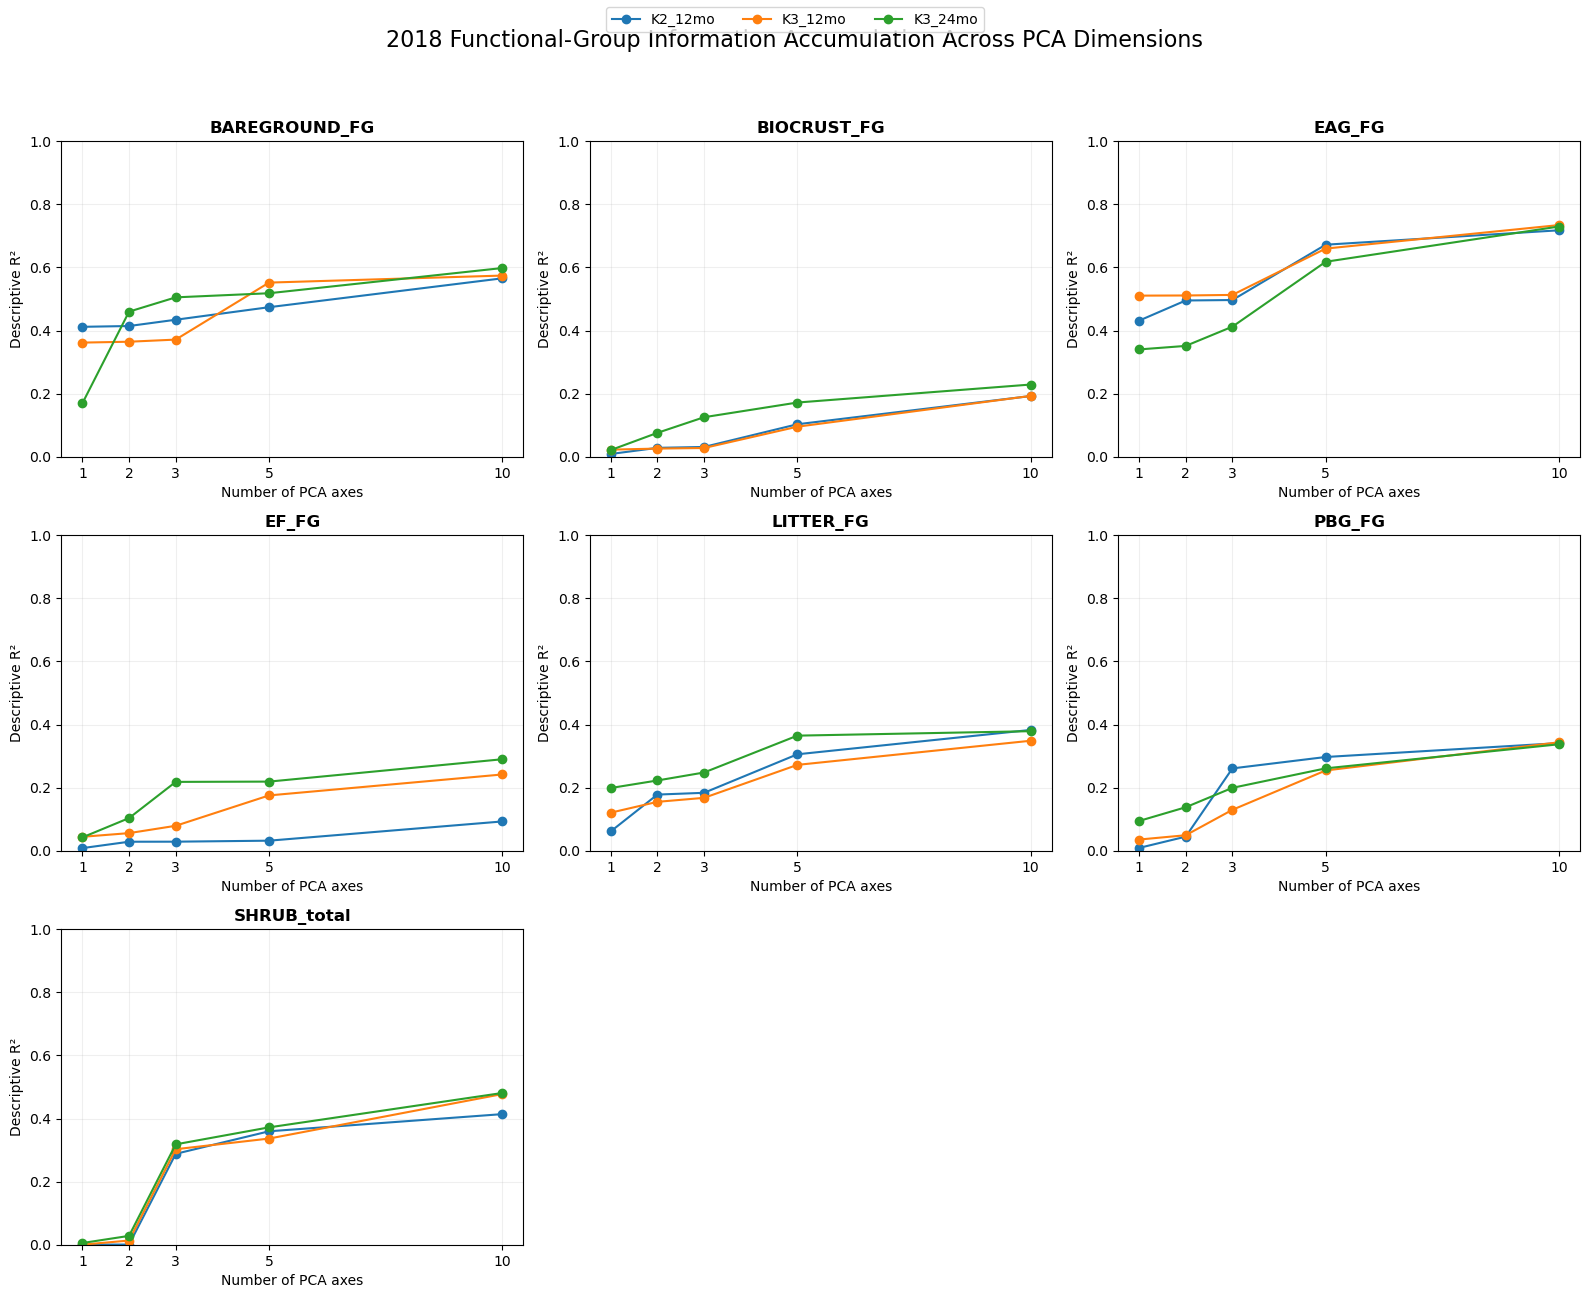

In [40]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 13),
)

axes = axes.ravel()


for ax, fg in zip(
    axes,
    FG_FEATURES_FOR_PCA,
):

    subset = (
        cumulative_fg_alignment.loc[
            cumulative_fg_alignment[
                "functional_group"
            ] == fg
        ]
    )

    for model_name in MODEL_ORDER:

        d = (
            subset.loc[
                subset["model"]
                == model_name
            ]
            .sort_values(
                "n_pc"
            )
        )

        ax.plot(
            d["n_pc"],
            d["R2"],
            marker="o",
            label=model_name,
        )

    ax.set_title(
        fg,
        fontweight="bold",
    )

    ax.set_xlabel(
        "Number of PCA axes"
    )

    ax.set_ylabel(
        "Descriptive R²"
    )

    ax.set_xticks(
        PC_COUNTS
    )

    ax.set_ylim(
        0,
        1
    )

    ax.grid(
        alpha=0.2
    )


for ax in axes[
    len(FG_FEATURES_FOR_PCA):
]:
    ax.axis("off")


handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
)

fig.suptitle(
    "2018 Functional-Group Information Accumulation "
    "Across PCA Dimensions",
    fontsize=16,
)

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.95,
    ]
)

plt.show()